In [1]:
import numpy as np
import matplotlib.pyplot as pl

In [2]:
ra = 0.5 #rad
dec = 0.5 #rad
eta = 0.5 #[-1,1]
psi = 0.5 #rad

lat = 0.5 #rad
lng = 0.5 #rad
az = 0.5 #rad

In [3]:
#Trig functions used in Eq. (11)-(12) of Astone2010
#Lines 39-49 of sour_ant_2_5vec.m
c_dec=np.cos(dec)
c_lat=np.cos(lat)
s_dec=np.sin(dec)
s_lat=np.sin(lat)

c_2az=np.cos(2*az)
c_2dec=np.cos(2*dec)
c_2lat=np.cos(2*lat)
s_2az=np.sin(2*az)
s_2dec=np.sin(2*dec)
s_2lat=np.sin(2*lat)

In [4]:
#Eq. (11)-(12) of Astone2010
#Lines 51-60 of sour_ant_2_5vec.m

a0=-(3/16)*(1+c_2dec)*(1+c_2lat)*c_2az
a1c=-(1/4)*s_2dec*s_2lat*c_2az
a1s=-(1/2)*s_2dec*c_lat*s_2az
a2c=(-1/16)*(3-c_2dec)*(3-c_2lat)*c_2az
a2s=-(1/4)*(3-c_2dec)*s_lat*s_2az

b1c=-c_dec*c_lat*s_2az
b1s=(1/2)*c_dec*s_2lat*c_2az
b2c=-s_dec*s_lat*s_2az
b2s=(1/4)*s_dec*(3-c_2lat)*c_2az

In [5]:
#Eq. (17)-(18) of Astone2010
#Lines 62-72 of sour_ant_2_5vec.m
A_p = np.empty((5), dtype=complex)
A_c = np.empty((5), dtype=complex)
al=np.exp(-1j*(ra-lng)) #=e^{-j(\alpha-\beta)} in Eq.(17)-(18)

A_p[0]=(al**-2)*(a2c+1j*a2s)/2
A_p[1]=(al**-1)*(a1c+1j*a1s)/2
A_p[2]=a0
A_p[3]=(al)*(a1c-1j*a1s)/2
A_p[4]=(al**2)*(a2c-1j*a2s)/2

A_c[0]=(al**-2)*(b2c+1j*b2s)/2
A_c[1]=(al**-1)*(b1c+1j*b1s)/2
A_c[2]=0
A_c[3]=(al)*(b1c-1j*b1s)/2
A_c[4]=(al**2)*(b2c-1j*b2s)/2

In [6]:
#Eq. (2)-(3) of Astone2010
#Lines 83-84 of sour_ant_2_5vec.m
H_p=np.sqrt(1/(1+eta**2))*(np.cos(2*psi)-1j*eta*np.sin(2*psi))
H_c=np.sqrt(1/(1+eta**2))*(np.sin(2*psi)+1j*eta*np.cos(2*psi))

In [7]:
#Eq. (16) of Astone2010
#Line 85 of sour_ant_2_5vec
A = H_p*A_p + H_c*A_c

## Testing behaviour

In [8]:
f0 = 2
omega0 = 2*np.pi*f0
gamma = 0
side_day= 1000#86164.09053083288
side_omega = 2*np.pi/side_day
t_space = np.arange(0, 2*side_day, 1/(20*f0))
monochromatic = 2*np.exp(1j*(omega0*t_space+gamma))

/home/neil/anaconda3/envs/ringdown/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.0, 10.0)

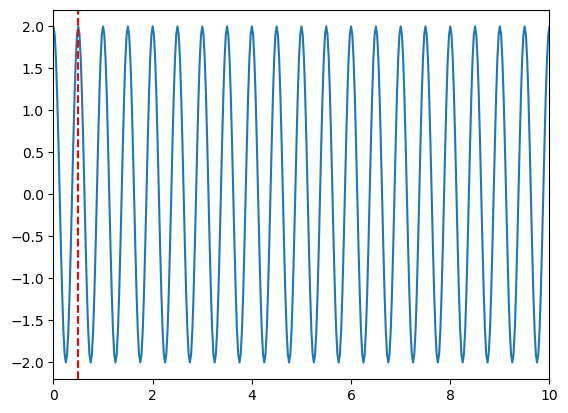

In [9]:
pl.plot(t_space, monochromatic)
pl.axvline(2*np.pi/omega0, c='r', ls='--')
pl.xlim(0, 10)

(1.997, 2.003)

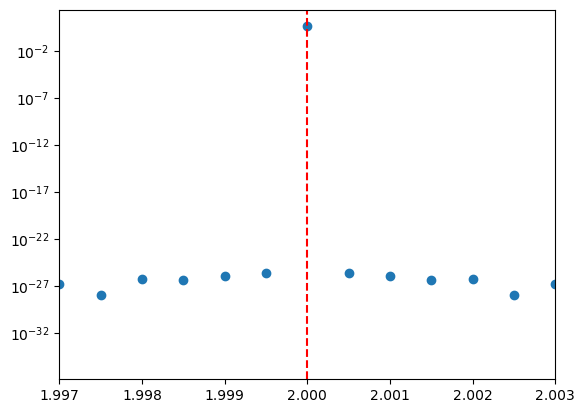

In [10]:
mono_freqs = np.fft.fftshift(np.fft.fftfreq(len(t_space), np.diff(t_space)[0]))
mono_power = abs(np.fft.fftshift(np.fft.fft(monochromatic)/len(monochromatic)))**2
pl.semilogy(mono_freqs, mono_power, 'o')
pl.axvline(f0, c='r', ls='--')
pl.xlim(f0-0.003, 2+0.003)

In [11]:
scalar_Aplus = a0+a1c*np.cos(side_omega*t_space)+a1s*np.sin(side_omega*t_space)+\
                a2c*np.cos(2*side_omega*t_space)+a2s*np.sin(2*side_omega*t_space)
scalar_Across = b1c*np.cos(side_omega*t_space)+b1s*np.sin(side_omega*t_space)+\
                b2c*np.cos(2*side_omega*t_space)+b2s*np.sin(2*side_omega*t_space)

In [12]:
scalar_Aplus

array([-0.54030231, -0.54042903, -0.54055574, ..., -0.53992199,
       -0.54004878, -0.54017556])

In [13]:
detector = (scalar_Aplus*H_p+scalar_Across*H_c)*monochromatic

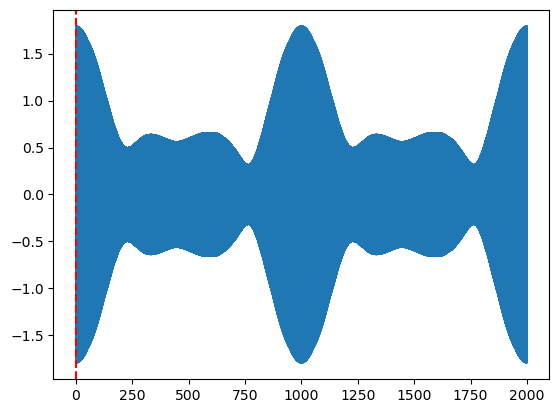

In [14]:
pl.plot(t_space, detector)
pl.axvline(2*np.pi/omega0, c='r', ls='--')
# pl.xlim(0, 1000)

(1.99, 2.01)

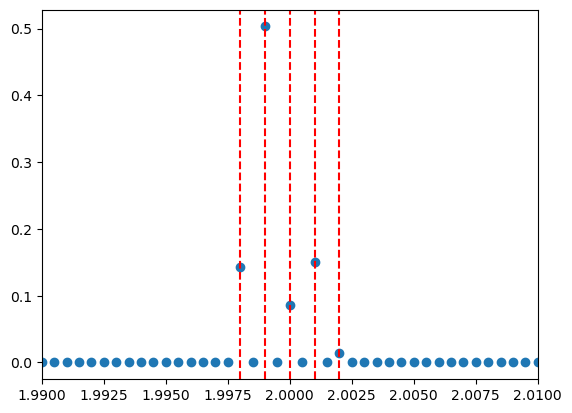

In [15]:
det_freqs = np.fft.fftshift(np.fft.fftfreq(len(t_space), np.diff(t_space)[0]))
det_power = abs(np.fft.fftshift(np.fft.fft(detector)/len(detector)))**2
det_weights = np.fft.fftshift(np.fft.fft(detector)/len(detector))
pl.plot(det_freqs, det_power, 'o')
pl.axvline(f0-2/side_day, c='r', ls='--')
pl.axvline(f0-1/side_day, c='r', ls='--')
pl.axvline(f0, c='r', ls='--')
pl.axvline(f0+1/side_day, c='r', ls='--')
pl.axvline(f0+2/side_day, c='r', ls='--')
pl.xlim(1.99, 2.01)

In [16]:
X = np.empty((5), dtype=complex)

X[0] = det_weights[abs(det_freqs-(f0-2/side_day)).argmin()]
X[1] = det_weights[abs(det_freqs-(f0-1/side_day)).argmin()]
X[2] = det_weights[abs(det_freqs-f0).argmin()]
X[3] = det_weights[abs(det_freqs-(f0+1/side_day)).argmin()]
X[4] = det_weights[abs(det_freqs-(f0+2/side_day)).argmin()]

In [18]:
abs(np.dot(X, A)/np.sum(np.abs(A)**2))

1.7459390199425482

In [17]:
abs(np.dot(X, np.conj(A))/np.sum(np.abs(A)**2))

2.0000000000000004

In [40]:
np.max(mono_power)

4.0